## Noise covariance mismatch: per-$\ell$ errorbar disagreement

A single-field, per-$\ell$ QML estimator (no bandpowering) with a big mask
so $F_\ell$ is full-rank and invertible.

**The point:** The fiducial pixel covariance uses white pixel noise
$\mathbb{N} = N_a/\omega_{\rm pix}\cdot I$ (full-rank, contributions at all $\ell$).
If the sims instead generate noise via `synalm(C_{aa})` (band-limited at
$\ell\le\ell_{\max}$), the true data covariance $\neq$ fiducial, and
Appendix A of Kvasiuk et al. 2025 shows that the actual estimator covariance is
$\tilde F^{-1}G\tilde F^{-1} \neq \tilde F^{-1}$.

We run both sim modes side by side:
1. **Mismatched:** `synalm(C_{aa})` — band-limited noise $\neq$ fiducial white noise
2. **Matched:** `synalm(S_{aa})` + pixel-space white noise — $C_{\rm true} = C_{\rm fid}$ exactly

Both use noise-bias subtraction so the means target $S_{aa}$.
Only the errorbars differ: **matched** agrees with $F^{-1}$, **mismatched** doesn't.

In [1]:
import sys
sys.path.append('./')
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import opt_einsum as oe
from tqdm import tqdm

from utilities import *
from qmlfast import *

### Setup

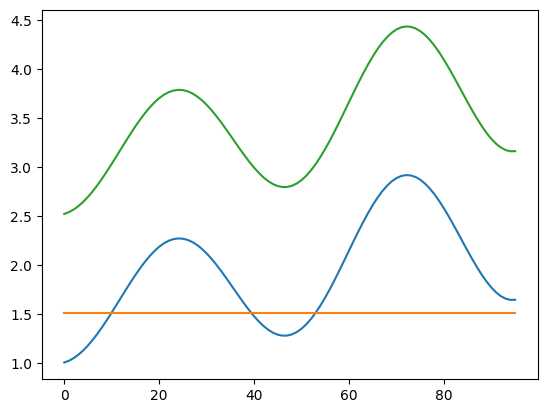

In [2]:
nside = 32
lmax = 3 * nside - 1
n_ell = 3 * nside
ell = np.arange(n_ell, dtype=float)

S_aa = np.exp((ell+1)/n_ell/2) * (1 + np.sin((ell+1)/n_ell*np.pi*2)**2)
N_a = 1.5*S_aa[0]
C_aa = S_aa + N_a

Nf = 1
plt.plot(ell, S_aa)
plt.plot(ell, N_a*np.ones_like(ell))
plt.plot(ell, C_aa*np.ones_like(ell))

### Mask (large sky fraction)

A single disc cut, keeping $\sim 65\%$ of the sky so $F_\ell$ is
full-rank and we can invert per-$\ell$ without binning.

/home/ykvasiuk/miniconda3/envs/pyccl/lib/python3.11/site-packages/healpy/pixelfunc.py:1507: RuntimeWarning: invalid value encountered in _get_neigbors_ring
  r = pixlib._get_neighbors_ring(nside, theta)


Sky fraction: 0.28
Np = 3392


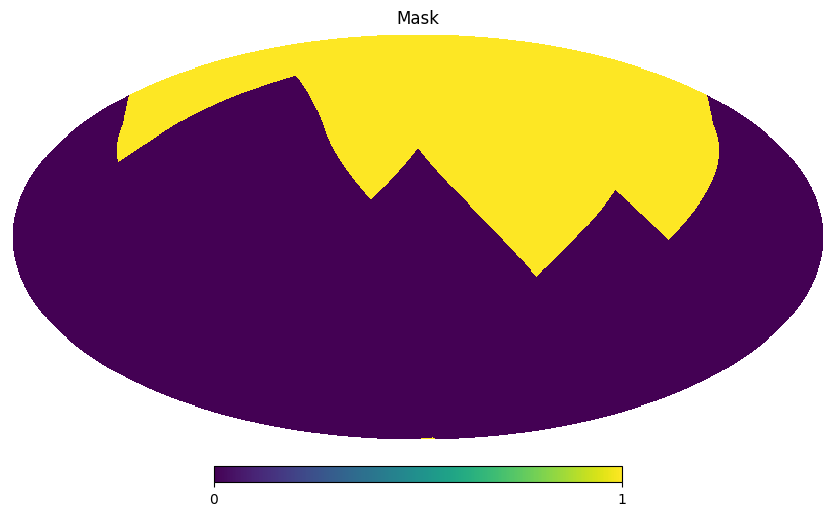

In [3]:
def gen_mask_patch(nside, seed, niter):
    npix = hp.nside2npix(nside)
    idx_bound = seed
    mask = np.zeros(npix)
    mask[seed] = 1
    masks = np.zeros((niter, npix))
    for i in range(niter):
        mask_idx = np.arange(npix)[mask != 0]
        idx = np.unique(hp.get_all_neighbours(nside, idx_bound).flatten())
        mask[idx] = 1
        masks[i] = mask
        idx_bound = np.unique(idx[~np.isin(idx, mask_idx)])
    return masks

masks = gen_mask_patch(nside, 600, 30)
mask = masks[28]
#hp.mollview(mask)
hp.mollview(mask, title='Mask')
print(f'Sky fraction: {mask.mean():.2f}')

theta, phi = theta_phi(nside)
theta = theta[mask == 1]
phi = phi[mask == 1]
Np = int(mask.sum())
omega_pix = 4 * np.pi / hp.nside2npix(nside)
print(f'Np = {Np}')

### Pixel covariance (signal + white pixel noise)

In [4]:
Pl_ij = get_Pl_ij(theta, phi, nside, lmax=lmax)

def get_pix_cov_block(cl, Pl_ij, lmin, lmax):
    return oe.contract('ijk,i->jk', Pl_ij[lmin:lmax], cl[lmin:lmax])

N_pix_diag = N_a / omega_pix
large_cov = get_pix_cov_block(S_aa, Pl_ij, 0, lmax + 1) + np.eye(Np) * N_pix_diag

print(f'cond(C_fid) = {np.linalg.cond(large_cov):.2e}')
Cinv = np.linalg.inv(large_cov)
C_map = np.ones((Nf, Nf))

cond(C_fid) = 4.14e+00


### Per-$\ell$ Fisher matrix

In [ ]:
Y_r_all = sph_harm_y_real_all(n_ell, theta, phi)

F_idx = np.array([(0, 0, l) for l in range(n_ell)])
V_packed, offsets, ranks = pack_sph_harm(Y_r_all)
F_ell = getF_packed(V_packed, offsets, ranks, Cinv, F_idx, Nf, Np, C_map)

print(f'F_ell shape: {F_ell.shape}')
print(f'F_ell rank:  {np.linalg.matrix_rank(F_ell)}')

invF = np.linalg.inv(F_ell)

### Noise bias

$b_\ell = \tfrac12\,\mathrm{Tr}(C^{-1} P_\ell C^{-1}\mathbb{N})
= \tfrac12\,(N_a/\omega)\,\mathrm{Tr}(C^{-2} P_\ell)$

In [ ]:
Cinv_sq = Cinv @ Cinv
noise_bias = 0.5 * N_pix_diag * np.einsum('ij,lji->l', Cinv_sq, Pl_ij[:n_ell])

### Run simulations: mismatched vs matched

Both use noise-bias subtraction. The only difference is how the noise is generated.

In [18]:
n_sims = 2000
rng = np.random.default_rng(42)

ys_mismatch = []   # synalm(C_aa): band-limited noise ≠ white noise fiducial
ys_match = []      # synalm(S_aa) + pixel noise: C_true = C_fid

for i in tqdm(range(n_sims)):
    # ── Mismatched: band-limited signal+noise via synalm(C_aa) ──
    alm_total = hp.synalm(C_aa, lmax=lmax)
    x_mis = np.array([hp.alm2map(alm_total, nside)[mask == 1]])
    y_mis = get_y_packed(x_mis, V_packed, offsets, ranks, Cinv, F_idx, Nf, Np)
    ys_mismatch.append(y_mis - noise_bias)

    # ── Matched: band-limited signal + pixel-space white noise ──
    alm_sig = hp.synalm(S_aa, lmax=lmax)
    sig = hp.alm2map(alm_sig, nside)[mask == 1]
    noise = rng.normal(0, np.sqrt(N_pix_diag), Np)
    x_mat = np.array([sig + noise])
    y_mat = get_y_packed(x_mat, V_packed, offsets, ranks, Cinv, F_idx, Nf, Np)
    ys_match.append(y_mat - noise_bias)

ys_mismatch = np.array(ys_mismatch)
ys_match = np.array(ys_match)
print(f'shapes: {ys_mismatch.shape}, {ys_match.shape}')

100%|███████████████████████████████████████| 2000/2000 [05:52<00:00,  5.68it/s]

shapes: (2000, 96), (2000, 96)


In [19]:
np.linalg.cond(invF)

44015.330441229606

### Appendix A: true analytic covariance of the mismatched estimator

When $C_{\rm fid} \neq C_{\rm true}$, $\mathrm{Cov}(\hat y) = G \neq \tilde F$,
where (Eq. 48 of the paper):

$$G_{\ell\ell'} = \tfrac12\,\mathrm{Tr}\!\left(
C_{\rm fid}^{-1} P_\ell\, C_{\rm fid}^{-1} C_{\rm true}\,
C_{\rm fid}^{-1} P_{\ell'}\, C_{\rm fid}^{-1} C_{\rm true}\right)$$

So the actual covariance of $\hat c = \tilde F^{-1}\hat y$ is
$\tilde F^{-1} G \tilde F^{-1}$, not $\tilde F^{-1}$.

We compute $G$ using the low-rank decomposition $P_\ell = V_\ell^T V_\ell$
to avoid storing full $N_p \times N_p$ matrices per $\ell$.

In [20]:
# True pixel covariance of mismatched sims: band-limited C_aa
C_true_mis = get_pix_cov_block(C_aa, Pl_ij, 0, lmax + 1)
W_mis = Cinv @ C_true_mis  # "whitened" true cov

# Precompute low-rank factors: u_l = Cinv V_l^T, v_l = V_l W_mis
u_list = []
v_list = []
for l in range(n_ell):
    r = 2*l + 1
    V_l = Y_r_all[l, :r, :]
    u_list.append(Cinv @ V_l.T)   # (Np, r_l)
    v_list.append(V_l @ W_mis)    # (r_l, Np)

# G_ll' = 0.5 * Tr(A_l A_l') where A_l = u_l @ v_l
# Using cyclic trace: Tr(u v u' v') = Tr((v u')(v' u)) = sum(K1 * K2.T)
G = np.zeros((n_ell, n_ell))
for l1 in tqdm(range(n_ell), desc='G matrix'):
    for l2 in range(l1 + 1):
        K1 = v_list[l1] @ u_list[l2]   # (r_l1, r_l2)
        K2 = v_list[l2] @ u_list[l1]   # (r_l2, r_l1)
        G[l1, l2] = 0.5 * np.sum(K1 * K2.T)
        G[l2, l1] = G[l1, l2]

print(f'G shape: {G.shape}')
print(f'||G - F||/||F|| = {np.linalg.norm(G - F_ell)/np.linalg.norm(F_ell):.3e}  '
      f'(should be > 0 for mismatch)')

G matrix: 100%|█████████████████████████████████| 96/96 [00:05<00:00, 19.19it/s]

G shape: (96, 96)
||G - F||/||F|| = 1.042e-01  (should be > 0 for mismatch)


In [21]:
c_mis = ys_mismatch @ invF.T
c_mat = ys_match @ invF.T

c_mean_mis = c_mis.mean(axis=0)
c_mean_mat = c_mat.mean(axis=0)
c_cov_mis = np.cov(c_mis, rowvar=False, ddof=1)
c_cov_mat = np.cov(c_mat, rowvar=False, ddof=1)

sigma_mis = np.sqrt(np.diag(c_cov_mis))
sigma_mat = np.sqrt(np.diag(c_cov_mat))
sigma_an  = np.sqrt(np.diag(invF))  # naive: assumes Cov(y) = F

# Appendix A: true analytic cov when fid != true
cov_appA = invF @ G @ invF
sigma_appA = np.sqrt(np.diag(cov_appA))


### Errorbar ratio: $\sigma_{\rm emp} / \sqrt{\mathrm{diag}\,F^{-1}}$

Mismatched should deviate from 1 (especially at high $\ell$); matched should
scatter around 1 within the expected $\pm 1/\sqrt{2(N-1)}$ band.

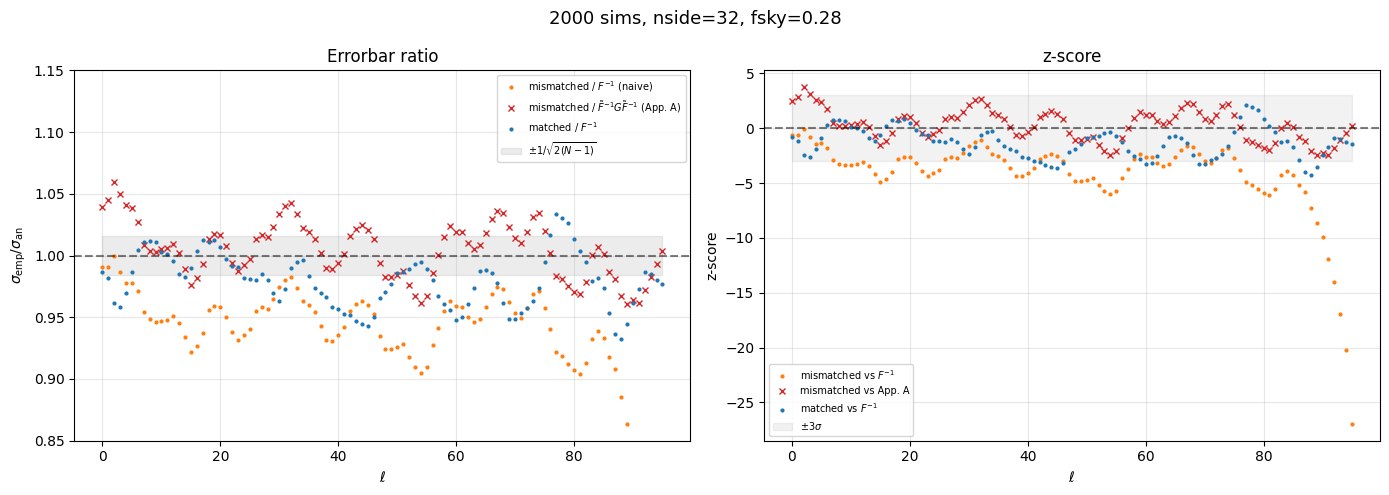

In [22]:
ratio_err = 1.0 / np.sqrt(2 * (n_sims - 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ell, sigma_mis / sigma_an, '.', ms=4, color='C1',
        label='mismatched / $F^{-1}$ (naive)')
ax.plot(ell, sigma_mis / sigma_appA, 'x', ms=5, color='C3',
        label=r'mismatched / $\tilde F^{-1}G\tilde F^{-1}$ (App. A)')
ax.plot(ell, sigma_mat / sigma_an, '.', ms=4, color='C0',
        label='matched / $F^{-1}$')
ax.axhline(1.0, color='k', ls='--', alpha=0.5)
ax.fill_between(ell, 1-ratio_err, 1+ratio_err, alpha=0.15, color='gray',
                label=fr'$\pm 1/\sqrt{{2(N-1)}}$')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\sigma_{\rm emp}/\sigma_{\rm an}$')
ax.set_title('Errorbar ratio')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
ax.set_ylim(0.85, 1.15)

ax = axes[1]
z_mis_naive = (sigma_mis / sigma_an - 1) / ratio_err
z_mis_appA  = (sigma_mis / sigma_appA - 1) / ratio_err
z_mat       = (sigma_mat / sigma_an - 1) / ratio_err
ax.plot(ell, z_mis_naive, '.', ms=4, color='C1', label='mismatched vs $F^{-1}$')
ax.plot(ell, z_mis_appA, 'x', ms=5, color='C3', label=r'mismatched vs App. A')
ax.plot(ell, z_mat, '.', ms=4, color='C0', label='matched vs $F^{-1}$')
ax.axhline(0, color='k', ls='--', alpha=0.5)
ax.fill_between(ell, -3, 3, alpha=0.1, color='gray', label=r'$\pm 3\sigma$')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel('z-score')
ax.set_title('z-score')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

plt.suptitle(f'{n_sims} sims, nside={nside}, fsky={mask.mean():.2f}', fontsize=13)
plt.tight_layout()
plt.show()


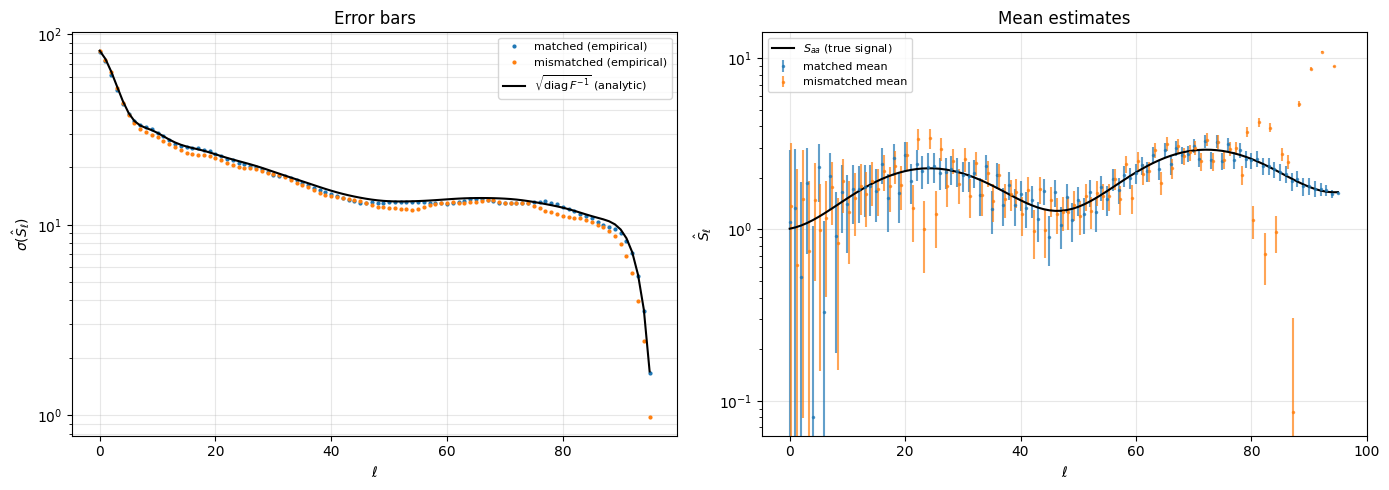

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(ell, sigma_mat, '.', ms=4, color='C0', label='matched (empirical)')
ax.semilogy(ell, sigma_mis, '.', ms=4, color='C1', label='mismatched (empirical)')
ax.semilogy(ell, sigma_an, 'k-', lw=1.5, label=r'$\sqrt{\mathrm{diag}\,F^{-1}}$ (analytic)')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\sigma(\hat S_\ell)$')
ax.set_title('Error bars')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

ax = axes[1]
ax.errorbar(ell, c_mean_mat, yerr=sigma_mat/np.sqrt(n_sims), fmt='.', ms=3,
            color='C0', label='matched mean', alpha=0.7)
ax.errorbar(ell + 0.3, c_mean_mis, yerr=sigma_mis/np.sqrt(n_sims), fmt='.', ms=3,
            color='C1', label='mismatched mean', alpha=0.7)
ax.plot(ell, S_aa, 'k-', lw=1.5, label='$S_{aa}$ (true signal)')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\hat S_\ell$')
ax.set_title('Mean estimates')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

### Summary statistics

In [24]:
ratio_mis = sigma_mis / sigma_an
ratio_mat = sigma_mat / sigma_an

print(f'Matched   — mean ratio: {ratio_mat.mean():.4f}, '
      f'std: {ratio_mat.std():.4f}, '
      f'max |z|: {np.max(np.abs((ratio_mat-1)/ratio_err)):.1f}')
print(f'Mismatched — mean ratio: {ratio_mis.mean():.4f}, '
      f'std: {ratio_mis.std():.4f}, '
      f'max |z|: {np.max(np.abs((ratio_mis-1)/ratio_err)):.1f}')

# Where is the mismatch worst?
worst = np.argmax(np.abs(ratio_mis - 1))
print(f'\nWorst mismatched bin: ell={worst}, '
      f'ratio={ratio_mis[worst]:.4f}, '
      f'z={((ratio_mis[worst]-1)/ratio_err):+.1f}')

Matched   — mean ratio: 0.9795, std: 0.0217, max |z|: 4.3
Mismatched — mean ratio: 0.9329, std: 0.0602, max |z|: 27.0

Worst mismatched bin: ell=95, ratio=0.5737, z=-27.0
